# Analyse semantic-retrieval predictions

Score BGE ranks against expected contact ids for the raw user query.

Pick `RECALL_MIN_SCORE` first, then score ranking under that cutoff:

- `RECALL_MIN_SCORE` sweep: precision, recall, F1 on nonempty queries, and correct-empty rate on empty in-scope queries
- recall@10 and recall@20 after the chosen cutoff
- hit@10 and hit@20 after the chosen cutoff

Write `eval/results/semantic_retrieval_min_score_sweep.csv` and `eval/results/semantic_retrieval_results.csv`, then visualise.


## 0. Setup


In [36]:
# %pip install -q pandas matplotlib

In [37]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repo root whether the kernel cwd is repo root or eval/analysis/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "analysis":
    # Notebook opened from eval/analysis/
    REPO_ROOT = REPO_ROOT.parents[1]
elif (REPO_ROOT / "eval").is_dir():
    # Already at repo root
    pass
else:
    # Navigate up until eval/predictions/
    for p in [REPO_ROOT, *REPO_ROOT.parents]:
        if (p / "eval" / "predictions").is_dir():
            REPO_ROOT = p
            break

# Define paths
GT_PATH = REPO_ROOT / "eval" / "datasets" / "recall" / "recall_queries.jsonl"
PRED_PATH = REPO_ROOT / "eval" / "predictions" / "semantic_retrieval" / "bge_base_en_v1.5.jsonl"
RESULTS_DIR = REPO_ROOT / "eval" / "results"
RESULTS_CSV = RESULTS_DIR / "semantic_retrieval_results.csv"

KS = (10, 20)
MODEL = "bge_base_en_v1.5"
RECALL_MIN_SCORES = [i / 100 for i in range(30, 85, 5)]
DEFAULT_RECALL_MIN_SCORE = 0.35
SWEEP_CSV = RESULTS_DIR / "semantic_retrieval_min_score_sweep.csv"

print("REPO_ROOT:", REPO_ROOT)
print("GT:", GT_PATH.exists(), GT_PATH)
print("PRED:", PRED_PATH.exists(), PRED_PATH)

REPO_ROOT: /Users/desmond/Documents/University/Y3/FP/imet
GT: True /Users/desmond/Documents/University/Y3/FP/imet/eval/datasets/recall/recall_queries.jsonl
PRED: True /Users/desmond/Documents/University/Y3/FP/imet/eval/predictions/semantic_retrieval/bge_base_en_v1.5.jsonl


## 1. Load

Read the prediction JSONL, join ground truth on `id`, dump into one DataFrame.


In [38]:
def load_jsonl(path: Path) -> list[dict]:
    """
    Load rows from a JSONL file then convert into a list of dictionaries.
    """
    rows: list[dict] = []

    # Read file line by line
    for line in path.read_text(encoding="utf-8").splitlines():
        # Skip empty lines
        if not line.strip():
            continue
        # Parse JSON and add to list
        rows.append(json.loads(line))

    return rows

def expected_contact_ids(expected: dict | None) -> list[int]:
    """
    Pull contact ids from the expected block and keep integers only.
    """
    raw = (expected or {}).get("contact_ids") or []
    ids: list[int] = []
    for item in raw:
        try:
            ids.append(int(item))
        except (TypeError, ValueError):
            continue
    return ids


def ranked_contact_ids(ranked: list | None) -> list[int]:
    """
    Keep predicted contact ids in rank order.
    """
    ids: list[int] = []
    for item in ranked or []:
        # Skip rows that are not objects with a contact_id
        if not isinstance(item, dict):
            continue
        try:
            # Store the id as an int so it can match expected contact ids
            ids.append(int(item["contact_id"]))
        except (KeyError, TypeError, ValueError):
            continue
    return ids


# Load ground truth and index by id
gt_by_id: dict[int, dict] = {}
for row in load_jsonl(GT_PATH):
    gt_by_id[int(row["id"])] = row

# Load predictions and join GT on id
joined_rows: list[dict] = []
for pred in load_jsonl(PRED_PATH):
    query_id = int(pred["id"])
    gt = gt_by_id.get(query_id)
    
    # Skip prediction rows with no matching ground truth
    if gt is None:
        continue
    expected = gt.get("expected") or {}
    expected_ids = expected_contact_ids(expected)
    ranked = pred.get("ranked") or []

    joined_rows.append(
        {
            "id": query_id,
            "query": gt.get("query", ""),
            "expected_ids": expected_ids,
            "n_expected": len(expected_ids),
            "ranked": ranked,
            "ranked_ids": ranked_contact_ids(ranked),
            "n_ranked": len(ranked),
            "latency_ms": pred.get("latency_ms"),
            "error": pred.get("error"),
        }
    )

raw = pd.DataFrame(joined_rows)
print(raw.shape)
print("nonempty:", int((raw["n_expected"] > 0).sum()), "empty:", int((raw["n_expected"] == 0).sum()))
raw.head()

(49, 9)
nonempty: 39 empty: 10


,id,query,expected_ids,n_expected,ranked,ranked_ids,n_ranked,latency_ms,error
0,1,who likes hiking,"[1, 48, 50, 87, 107, 132, 140, 143]",8,"[{'contact_id': 125, 'score': 0.5693}, {'conta...","[125, 48, 107, 1, 86, 82, 103, 15, 99, 5, 110,...",20,135.64,None
1,2,who boulders or climbs,"[4, 5, 25, 27, 44, 55, 62, 68, 77, 82, 98, 113...",16,"[{'contact_id': 5, 'score': 0.673}, {'contact_...","[5, 128, 62, 77, 113, 82, 118, 144, 44, 4, 125...",20,42.80,None
2,3,who works in fintech,"[3, 4, 44, 58, 67, 98, 105, 115]",8,"[{'contact_id': 58, 'score': 0.652}, {'contact...","[58, 98, 3, 4, 105, 44, 76, 2, 80, 132, 56, 88...",20,39.13,None
3,4,who is a product designer,"[20, 42, 79, 101, 113, 116, 138, 139]",8,"[{'contact_id': 20, 'score': 0.6698}, {'contac...","[20, 42, 79, 88, 138, 116, 123, 4, 49, 69, 139...",20,20.74,None
4,5,who did I meet at the career fair,"[1, 2, 55, 56, 67, 76]",6,"[{'contact_id': 67, 'score': 0.6642}, {'contac...","[67, 98, 125, 105, 116, 56, 79, 76, 90, 40, 14...",20,28.45,None


## 2. RECALL_MIN_SCORE sweep

Find the cosine cutoff before scoring recall@k and hit@k.

- Nonempty queries (1-39): macro precision, recall, F1 of kept ids vs ground truths.
- Empty queries (40-49): `correct_empty_rate` (kept list is empty).

This is the raw vector pool (top 20, no FTS, no LLM filter).


In [ ]:
def row_has_error(error) -> bool:
    """
    True when the prediction stored a real error string.
    Pandas stores a null error as NaN, which is not an error.
    """
    if error is None:
        return False
    if isinstance(error, float) and math.isnan(error):
        return False
    return True


def ranked_ids_at_min_score(ranked, min_score: float) -> list[int]:
    """
    Keep predicted contact ids whose cosine is at least min_score, in rank order.
    Same rule as production: drop vector hits below RECALL_MIN_SCORE.
    """
    kept: list[int] = []
    for item in ranked or []:
        # Skip rows that are not objects with score and contact_id
        if not isinstance(item, dict):
            continue
        try:
            score = float(item["score"])
            contact_id = int(item["contact_id"])
        except (KeyError, TypeError, ValueError):
            continue
        # Keep this contact if it clears the cosine cutoff
        if score >= min_score:
            kept.append(contact_id)
    return kept


def set_pred_recall_f1(expected: set[int], predicted: set[int]) -> tuple[float, float, float]:
    """
    Precision, recall, and F1 on contact-id sets.
    Empty prediction against non-empty expected is 0, 0, 0.
    """
    # No ground truths: P/R/F1 are not defined for this bucket
    if not expected:
        return float("nan"), float("nan"), float("nan")
    # Cutoff wiped the list on a query that should have answers
    if not predicted:
        return 0.0, 0.0, 0.0

    # Hits that are both predicted and expected
    overlap = len(expected & predicted)
    precision = overlap / len(predicted)
    recall = overlap / len(expected)
    # Harmonic mean; 0 if either side is 0
    if precision + recall:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0.0
    return precision, recall, f1


def score_min_score(frame: pd.DataFrame, min_score: float) -> dict:
    """
    Macro P/R/F1 on nonempty queries and correct-empty rate on empty queries
    for one RECALL_MIN_SCORE value.
    """
    # Split by whether ground truth lists any contacts
    nonempty = frame[frame["n_expected"] > 0]
    empty = frame[frame["n_expected"] == 0]

    precisions: list[float] = []
    recalls: list[float] = []
    f1s: list[float] = []
    # Queries 1-39: there is at least one expected contact
    for _, row in nonempty.iterrows():
        # Skip retrieve failures
        if row_has_error(row["error"]):
            continue
        # Apply the cosine cutoff then score against gold ids
        predicted = set(ranked_ids_at_min_score(row["ranked"], min_score))
        precision, recall, f1 = set_pred_recall_f1(set(row["expected_ids"]), predicted)
        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    empty_correct: list[float] = []
    # Queries 40-49: gold is empty, so the right list is no contacts
    for _, row in empty.iterrows():
        # Skip retrieve failures
        if row_has_error(row["error"]):
            continue
        predicted = ranked_ids_at_min_score(row["ranked"], min_score)
        # 1 if the cutoff dropped every hit, else 0
        empty_correct.append(float(len(predicted) == 0))

    return {
        "recall_min_score": min_score,
        "n_nonempty": len(precisions),
        "precision": float(pd.Series(precisions).mean()) if precisions else None,
        "recall": float(pd.Series(recalls).mean()) if recalls else None,
        "f1": float(pd.Series(f1s).mean()) if f1s else None,
        "n_empty": len(empty_correct),
        "correct_empty_rate": float(pd.Series(empty_correct).mean()) if empty_correct else None,
    }


# Score every cutoff in RECALL_MIN_SCORES (0.30 to 0.80, step 0.05)
sweep_rows = [score_min_score(raw, min_score) for min_score in RECALL_MIN_SCORES]
sweep = pd.DataFrame(sweep_rows)
# Overwrite the sweep CSV so the report can read it later
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sweep.to_csv(SWEEP_CSV, index=False)
print(f"Wrote {len(sweep)} rows to {SWEEP_CSV.relative_to(REPO_ROOT)}")

# Highest mean F1 on the nonempty queries
best_f1 = sweep["f1"].max()
best = sweep.loc[sweep["f1"].idxmax()]
print(
    f"Best nonempty F1={best_f1:.3f} at RECALL_MIN_SCORE={best['recall_min_score']}"
)
sweep


Wrote 11 rows to eval/results/semantic_retrieval_min_score_sweep.csv
Best nonempty F1=0.507 at RECALL_MIN_SCORE=0.55


,recall_min_score,n_nonempty,precision,recall,f1,n_empty,correct_empty_rate
0,0.30,39,0.265385,0.766725,0.374233,10,0.0
1,0.35,39,0.265385,0.766725,0.374233,10,0.0
2,0.40,39,0.265385,0.766725,0.374233,10,0.0
3,0.45,39,0.269231,0.758178,0.372718,10,0.0
4,0.50,39,0.311831,0.747673,0.397145,10,0.2
5,0.55,39,0.477429,0.656981,0.506530,10,0.6
6,0.60,39,0.585897,0.477029,0.445754,10,0.9
7,0.65,39,0.366839,0.211606,0.222900,10,1.0
8,0.70,39,0.209402,0.090093,0.116831,10,1.0
9,0.75,39,0.076923,0.013442,0.021756,10,1.0


## 3. RECALL_MIN_SCORE chart

Nonempty F1 vs empty-query correct rate. The current production default is 0.35.

The next cell takes the cutoff with the best nonempty F1. Override it there if the chart says otherwise.


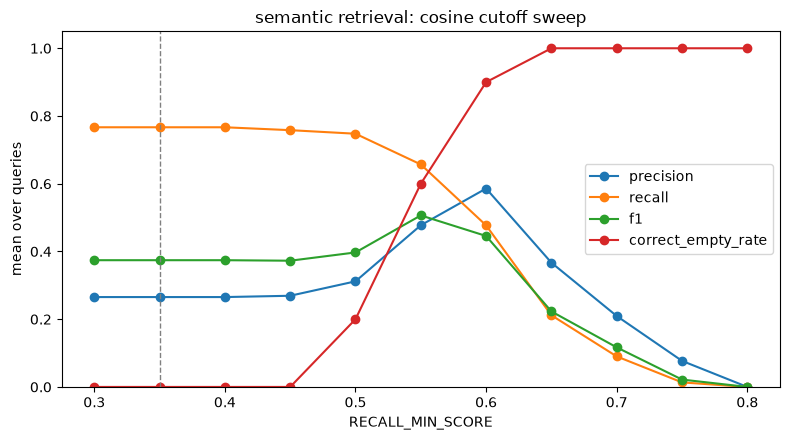

,precision,recall,f1,correct_empty_rate
recall_min_score,,,,
0.30,0.265385,0.766725,0.374233,0.0
0.35,0.265385,0.766725,0.374233,0.0
0.40,0.265385,0.766725,0.374233,0.0
0.45,0.269231,0.758178,0.372718,0.0
0.50,0.311831,0.747673,0.397145,0.2
0.55,0.477429,0.656981,0.506530,0.6
0.60,0.585897,0.477029,0.445754,0.9
0.65,0.366839,0.211606,0.222900,1.0
0.70,0.209402,0.090093,0.116831,1.0


In [40]:
ax = sweep.set_index("recall_min_score")[
    ["precision", "recall", "f1", "correct_empty_rate"]
].plot(kind="line", marker="o", figsize=(8, 4.5))
ax.set_ylim(0, 1.05)
ax.set_xlabel("RECALL_MIN_SCORE")
ax.set_ylabel("mean over queries")
ax.set_title("semantic retrieval: cosine cutoff sweep")
ax.axvline(DEFAULT_RECALL_MIN_SCORE, color="gray", linestyle="--", linewidth=1)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

sweep.set_index("recall_min_score")[
    ["precision", "recall", "f1", "correct_empty_rate"]
]

In [41]:
# Cutoff used for recall@k / hit@k below.
# Default: best nonempty F1 on the sweep. Override after looking at the chart if you want.
CHOSEN_RECALL_MIN_SCORE = float(sweep.loc[sweep["f1"].idxmax(), "recall_min_score"])
print(f"CHOSEN_RECALL_MIN_SCORE={CHOSEN_RECALL_MIN_SCORE}")


CHOSEN_RECALL_MIN_SCORE=0.55


## 4. Score each row

Apply `CHOSEN_RECALL_MIN_SCORE`, then for each nonempty query:

- **recall@k** fraction of expected ids in the kept top k
- **hit@k** 1 if at least one expected id is in the kept top k


In [42]:
def n_overlap(expected_ids: list[int], ranked_ids: list[int], k: int) -> int:
    """
    Count how many expected ids appear in the first k predicted ids.
    """
    top = set(ranked_ids[:k])
    return sum(1 for contact_id in expected_ids if contact_id in top)


def recall_at_k(expected_ids: list[int], ranked_ids: list[int], k: int) -> float:
    """
    Fraction of expected contacts that appear in the top k.
    """
    return n_overlap(expected_ids, ranked_ids, k) / len(expected_ids)


def hit_at_k(expected_ids: list[int], ranked_ids: list[int], k: int) -> float:
    """
    1 if at least one expected contact is in the top k, else 0.
    """
    return 1.0 if n_overlap(expected_ids, ranked_ids, k) >= 1 else 0.0


def score_row(row: pd.Series) -> dict:
    """
    Score one joined prediction row.
    """
    expected_ids = list(row["expected_ids"])
    ranked_ids = ranked_ids_at_min_score(row["ranked"], CHOSEN_RECALL_MIN_SCORE)
    error = row["error"]
    failed = row_has_error(error)

    scored = {
        "id": row["id"],
        "query": row["query"],
        "n_expected": row["n_expected"],
        "n_ranked": len(ranked_ids),
        "latency_ms": row["latency_ms"],
        "error": error,
    }

    # Skip recall and hit when the retrieve step failed
    for k in KS:
        if failed:
            scored[f"recall@{k}"] = None
            scored[f"hit@{k}"] = None
        else:
            scored[f"recall@{k}"] = recall_at_k(expected_ids, ranked_ids, k)
            scored[f"hit@{k}"] = hit_at_k(expected_ids, ranked_ids, k)

    return scored


# Convert per-query scores into DataFrame
nonempty_raw = raw[raw["n_expected"] > 0]
scored = pd.DataFrame([score_row(row) for _, row in nonempty_raw.iterrows()])
print(scored.shape)
scored.head()


(39, 10)


,id,query,n_expected,n_ranked,latency_ms,error,recall@10,hit@10,recall@20,hit@20
0,1,who likes hiking,8,1,135.64,None,0.000,0.0,0.000000,0.0
1,2,who boulders or climbs,16,11,42.80,None,0.625,1.0,0.625000,1.0
2,3,who works in fintech,8,20,39.13,None,0.750,1.0,1.000000,1.0
3,4,who is a product designer,8,9,20.74,None,0.625,1.0,0.625000,1.0
4,5,who did I meet at the career fair,6,20,28.45,None,0.500,1.0,0.666667,1.0


## 5. Aggregate

- **Recall / hit** = mean over nonempty queries after `CHOSEN_RECALL_MIN_SCORE`


In [43]:
def mean_metric(frame: pd.DataFrame, column: str) -> tuple[float | None, int]:
    """
    Mean of a metric column, ignoring missing values.
    """
    values = pd.to_numeric(frame[column], errors="coerce").dropna()
    if values.empty:
        return None, 0
    return float(values.mean()), int(len(values))


# Keep rows with no retrieve error
cleaned_rows = scored[~scored["error"].map(row_has_error)].copy()

result_rows: list[dict] = []

# Mean latency across scored queries
latency_mean = (
    float(pd.to_numeric(cleaned_rows["latency_ms"], errors="coerce").mean())
    if not cleaned_rows.empty
    else None
)

# Macro-average recall and hit
for k in KS:
    value, n = mean_metric(cleaned_rows, f"recall@{k}")
    result_rows.append(
        {
            "model": MODEL,
            "metric": f"recall@{k}",
            "value": value,
            "n": n,
            "recall_min_score": CHOSEN_RECALL_MIN_SCORE,
            "latency_ms_mean": latency_mean,
        }
    )
    value, n = mean_metric(cleaned_rows, f"hit@{k}")
    result_rows.append(
        {
            "model": MODEL,
            "metric": f"hit@{k}",
            "value": value,
            "n": n,
            "recall_min_score": CHOSEN_RECALL_MIN_SCORE,
            "latency_ms_mean": latency_mean,
        }
    )

# Convert long-format metric rows into a DataFrame
results = pd.DataFrame(result_rows)

# Wide table for a quick look
if results.empty:
    print("No rows without errors. Check the prediction JSONL error field (Postgres may have been down).")
    agg = results
else:
    agg = results.set_index("metric")[["value", "n", "recall_min_score", "latency_ms_mean"]]
    print(f"{MODEL}: {len(cleaned_rows)} queries")
agg


bge_base_en_v1.5: 39 queries


,value,n,recall_min_score,latency_ms_mean
metric,,,,
recall@10,0.575344,39,0.55,37.6
hit@10,0.897436,39,0.55,37.6
recall@20,0.656981,39,0.55,37.6
hit@20,0.923077,39,0.55,37.6


## 6. Save

Overwrite `eval/results/semantic_retrieval_results.csv`.


In [44]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Convert results df to CSV
results.to_csv(RESULTS_CSV, index=False)
print(f"Wrote {len(results)} rows to {RESULTS_CSV.relative_to(REPO_ROOT)}")
results

Wrote 4 rows to eval/results/semantic_retrieval_results.csv


,model,metric,value,n,recall_min_score,latency_ms_mean
0,bge_base_en_v1.5,recall@10,0.575344,39,0.55,37.6
1,bge_base_en_v1.5,hit@10,0.897436,39,0.55,37.6
2,bge_base_en_v1.5,recall@20,0.656981,39,0.55,37.6
3,bge_base_en_v1.5,hit@20,0.923077,39,0.55,37.6


## 7. Visualisation

Recall@k and Hit@k for BGE on the raw user query, after `CHOSEN_RECALL_MIN_SCORE`.


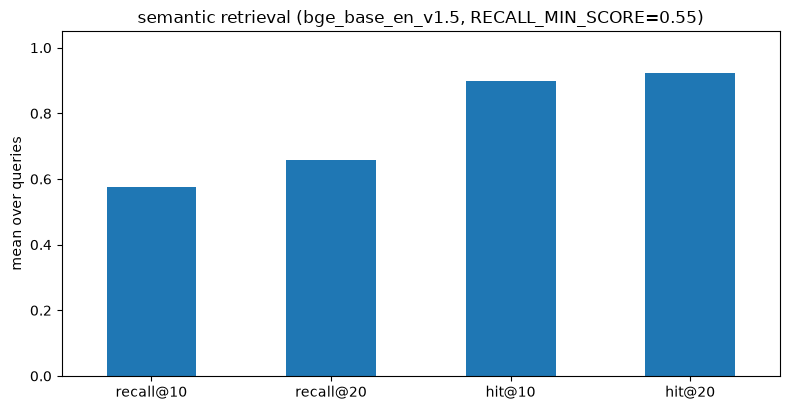

In [45]:
# Bar chart of recall and hit for BGE on the raw user query
metric_order = [f"recall@{k}" for k in KS] + [f"hit@{k}" for k in KS]
plot_df = results.set_index("metric").reindex(metric_order)

ax = plot_df["value"].plot(kind="bar", figsize=(8, 4.2), rot=0, legend=False)
ax.set_ylim(0, 1.05)
ax.set_ylabel("mean over queries")
ax.set_xlabel("")
ax.set_title(f"semantic retrieval ({MODEL}, RECALL_MIN_SCORE={CHOSEN_RECALL_MIN_SCORE})")
plt.tight_layout()
plt.show()
